In [3]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv('train.csv')

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



# working with qualitative data

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
#handling missing values
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/var/folders/4g/9m2h6m6x0lxbsngvlhdmn_dm0000gn/T/ipykernel_20151/361879076.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

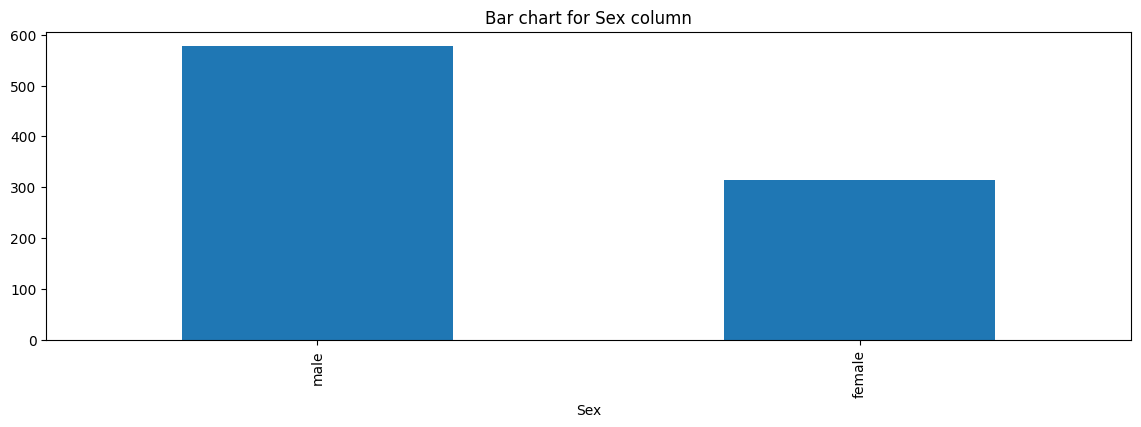

In [9]:
# Sex column
import matplotlib.pyplot as plt
plt.figure(figsize=(14,4))
plt.title('Bar chart for Sex column')
df['Sex'].value_counts().plot(kind='bar')
plt.show()

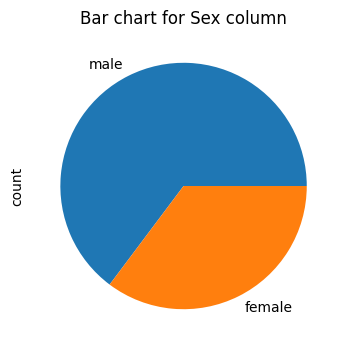

In [10]:
plt.figure(figsize=(14,4))
plt.title('Bar chart for Sex column')
df['Sex'].value_counts().plot(kind='pie')
plt.show()

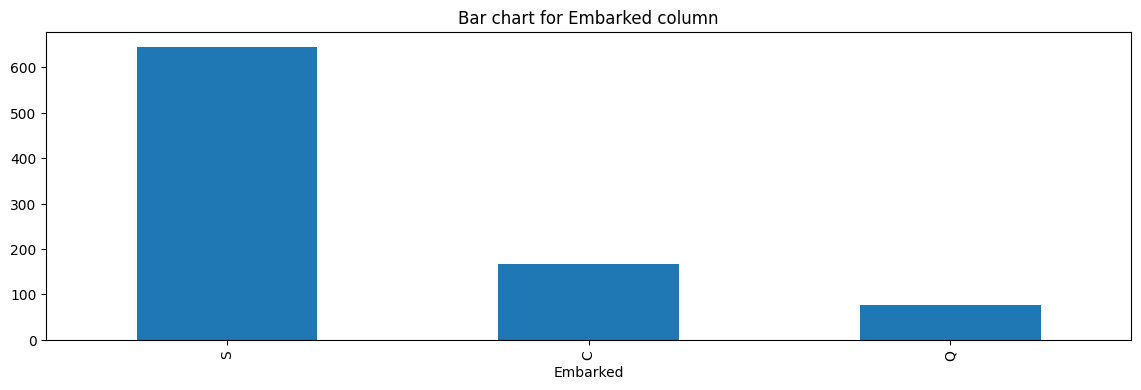

In [11]:
# bar chart for embarked column
plt.figure(figsize = (14,4))
plt.title('Bar chart for Embarked column')
df['Embarked'].value_counts().plot(kind = 'bar')
plt.show()

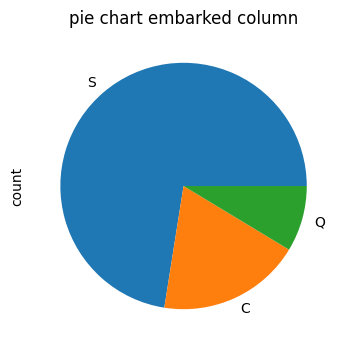

In [12]:
# pie chart for embarked column
plt.figure(figsize = (14,4))
plt.title('pie chart embarked column')
df['Embarked'].value_counts().plot(kind = 'pie')
plt.show()

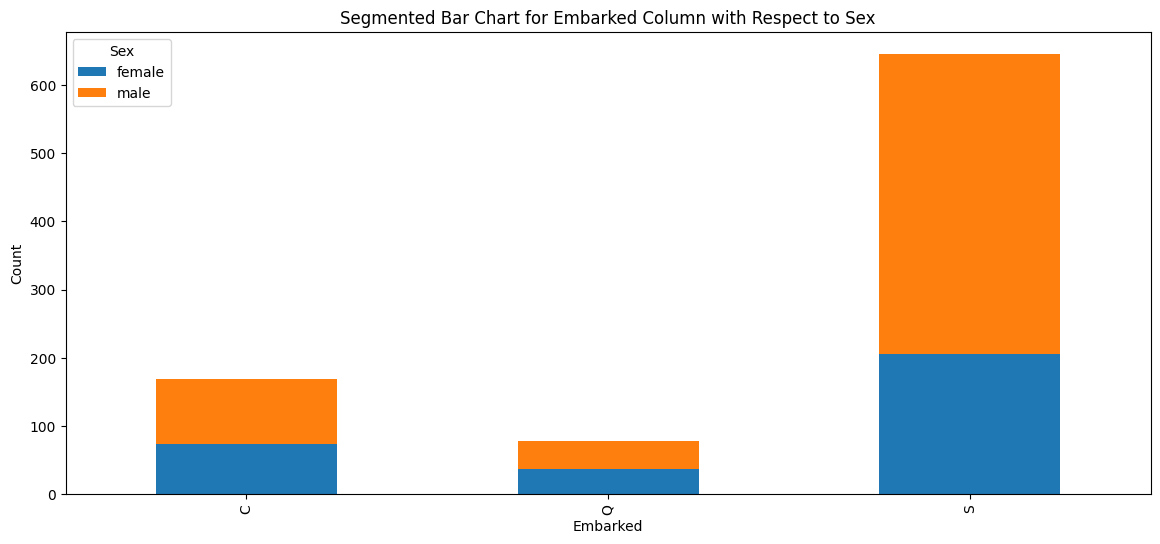

In [13]:
# segmented bar chart for embarked column with respect to sex
segmented_data = df.groupby(['Embarked', 'Sex']).size().unstack()
segmented_data.plot(kind='bar', stacked=True, figsize=(14, 6), title='Segmented Bar Chart for Embarked Column with Respect to Sex')
plt.ylabel('Count')
plt.show()

In [14]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
589,590,0,3,"Murdlin, Mr. Joseph",male,NaN,0,0,A./5. 3235,8.0500,NaN,S
786,787,1,3,"Sjoblom, Miss. Anna Sofia",female,18.0,0,0,3101265,7.4958,NaN,S
449,450,1,1,"Peuchen, Major. Arthur Godfrey",male,52.0,0,0,113786,30.5000,C104,S
585,586,1,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.6500,E68,S
666,667,0,2,"Butler, Mr. Reginald Fenton",male,25.0,0,0,234686,13.0000,NaN,S
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
90,91,0,3,"Christmann, Mr. Emil",male,29.0,0,0,343276,8.0500,NaN,S
387,388,1,2,"Buss, Miss. Kate",female,36.0,0,0,27849,13.0000,NaN,S
456,457,0,1,"Millet, Mr. Francis Davis",male,65.0,0,0,13509,26.5500,E38,S
500,501,0,3,"Calic, Mr. Petar",male,17.0,0,0,315086,8.6625,NaN,S


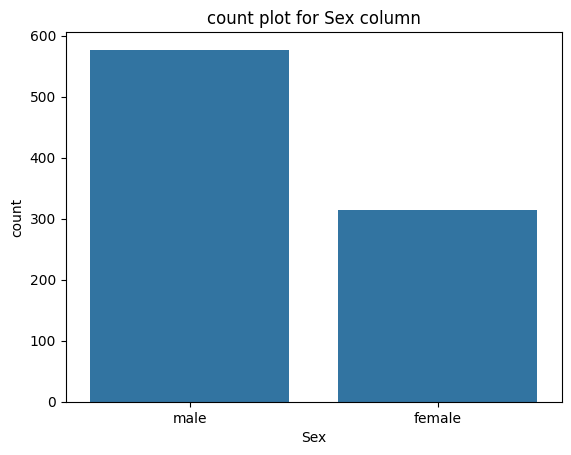

In [15]:
# count plot 
import seaborn as sns
sns.countplot(x = 'Sex', data = df)
plt.title('count plot for Sex column')
plt.show()

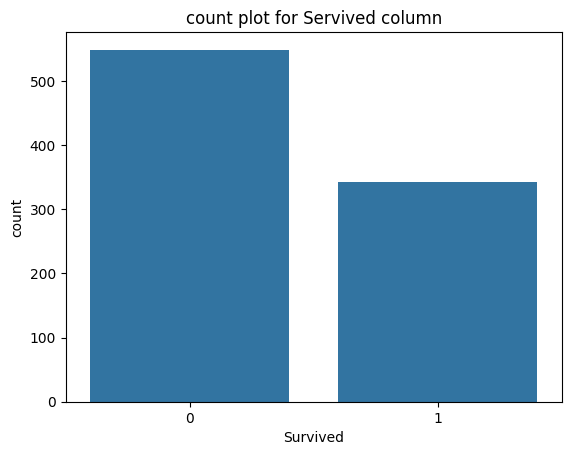

In [16]:
# count plot for servived column
sns.countplot(x= 'Survived',data=df)
plt.title('count plot for Servived column')
plt.show()


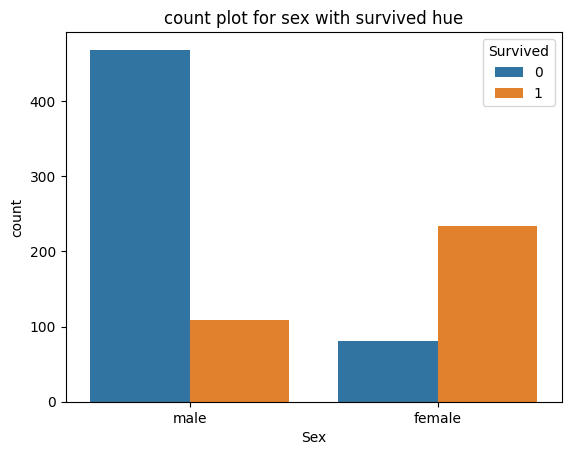

In [17]:
# count plot with hue 
sns.countplot(x='Sex',hue='Survived',data = df)
plt.title("count plot for sex with survived hue")
plt.show()

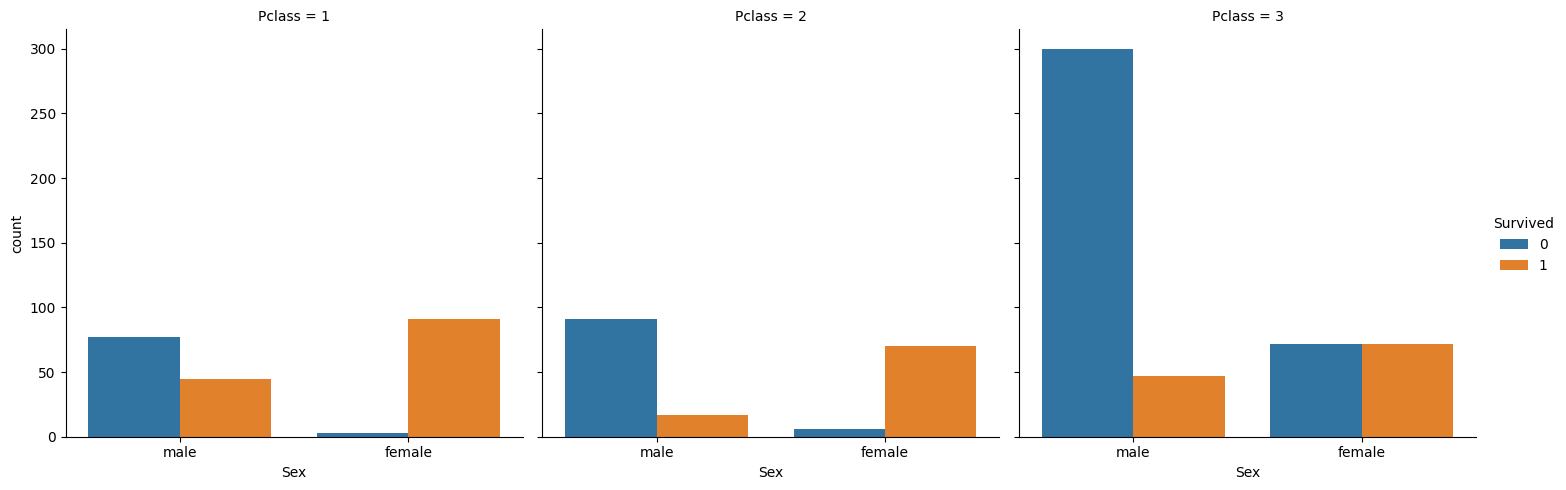

In [18]:
# cat plot with 3 variables 
sns.catplot(
    x='Sex',
    hue='Survived',
    col = 'Pclass',
    data = df,
    kind = 'count'
)
# plt.title('survival by sex and class')
plt.show()

In [19]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: xlabel='Sex,Pclass'>

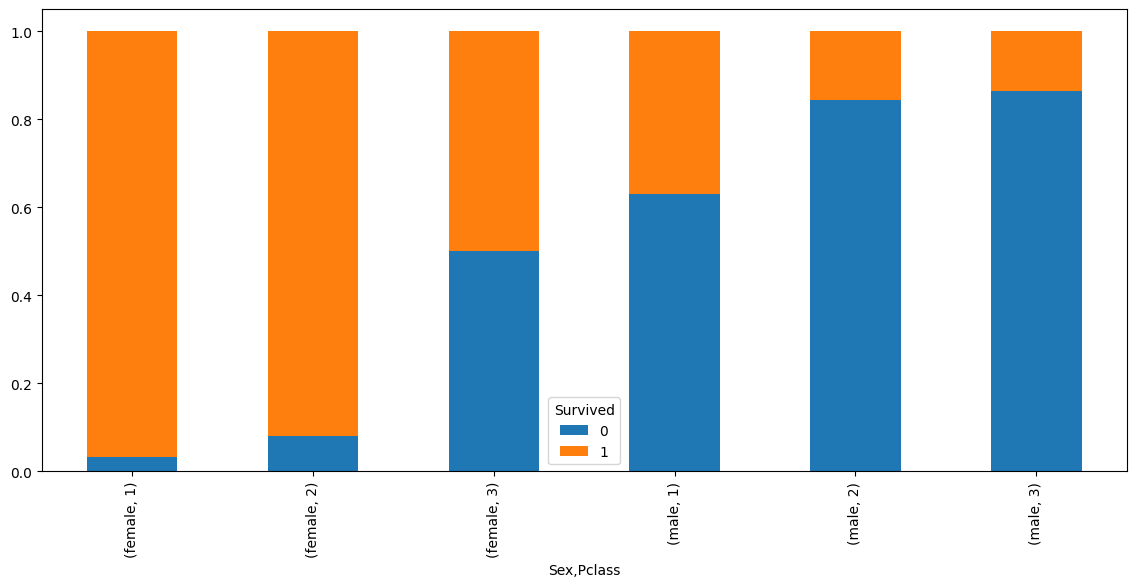

In [20]:
# stacked bar chart
pd.crosstab(
    [df['Sex'],df['Pclass']],
    df['Survived'],
    normalize='index'
).plot(kind = 'bar',stacked = True, figsize = (14,6))

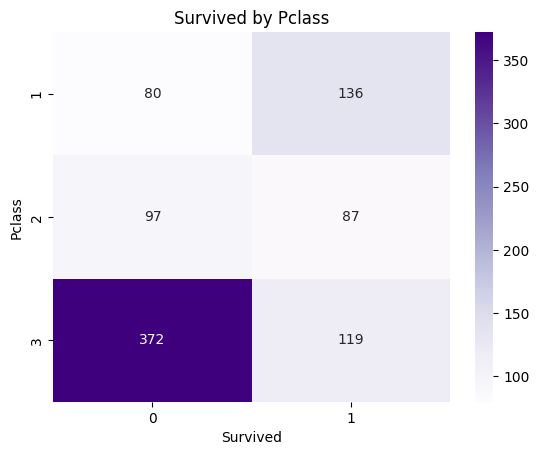

In [23]:
ct = pd.crosstab(df['Pclass'],df['Survived'])

sns.heatmap(ct,annot =True,fmt ='d',cmap = 'Purples')
plt.title('Survived by Pclass')
plt.xlabel('Survived')
plt.ylabel('Pclass')
plt.show()


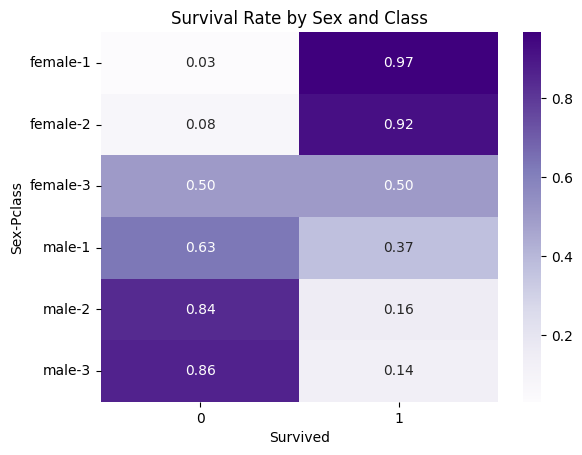

In [24]:
ct = pd.crosstab(
    [df['Sex'], df['Pclass']],
    df['Survived'],
    normalize='index'
)

sns.heatmap(ct, annot=True, fmt='.2f', cmap='Purples')
plt.title('Survival Rate by Sex and Class')
plt.show()
